# 🏨 Predicción de Cancelación de Reservas Hoteleras
##  Máster en Data Science & IA · Evolve Academy

**Dataset:** Hotel Booking Demand — Antonio, Almeida & Nunes (2019)  
**Tarea:** Clasificación binaria · `is_canceled` (37% positivos)   
**Objetivo:** Predecir aquellas reservas que tienen una alta probabilidad de ser cancaledas.  

## 0. Entorno y dependencias

In [5]:
# Instalar dependencias si es necesario
# !pip install pandas scikit-learn xgboost lightgbm optuna shap imbalanced-learn matplotlib seaborn


In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    RocCurveDisplay, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
    precision_recall_curve
)
from sklearn.model_selection import train_test_split

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

import dalex as dx

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_style("whitegrid")
RANDOM_STATE = 42


## 1. Carga y primera inspección

El dataset es público y está disponible directamente desde el repositorio de TidyTuesday (espejo del paper original).
También puede descargarse desde Kaggle: `jessemostipak/hotel-booking-demand`.


In [7]:
df_raw = pd.read_csv("reservas_hoteleras.csv")
print(df_raw.shape)
df_raw.head(3)


(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0000,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0000,0,0,Check-Out,2015-07-02


### Diccionario de variables
*Fuente: Antonio, Almeida & Nunes (2019). Hotel booking demand datasets. Data in Brief, 22, 41–49.*

| Variable | Tipo | Descripción |
|---|---|---|
| `hotel` | Categórica | Tipo de hotel: H1 = Resort Hotel, H2 = City Hotel |
| `is_canceled` | Binaria (target) | 1 = reserva cancelada, 0 = no cancelada |
| `lead_time` | Numérica | Días entre la fecha de reserva y la fecha de llegada |
| `arrival_date_year` | Numérica | Año de llegada |
| `arrival_date_month` | Categórica | Mes de llegada |
| `arrival_date_week_number` | Numérica | Semana del año de llegada |
| `arrival_date_day_of_month` | Numérica | Día del mes de llegada |
| `stays_in_weekend_nights` | Numérica | Noches de fin de semana reservadas |
| `stays_in_week_nights` | Numérica | Noches entre semana reservadas |
| `adults` / `children` / `babies` | Numérica | Composición del grupo |
| `meal` | Categórica | Régimen alimenticio |
| `country` | Categórica | País de origen del cliente |
| `market_segment` / `distribution_channel` | Categórica | Canal de captación/distribución |
| `is_repeated_guest` | Binaria | Cliente repetidor |
| `previous_cancellations` / `previous_bookings_not_canceled` | Numérica | Historial del cliente |
| `reserved_room_type` / `assigned_room_type` | Categórica | Tipo de habitación reservada / asignada |
| `booking_changes` | Numérica | Nº de modificaciones sobre la reserva |
| `deposit_type` | Categórica | No Deposit / Non Refund / Refundable |
| `agent` / `company` | Categórica (ID) | Agencia / empresa (anonimizadas) |
| `days_in_waiting_list` | Numérica | Días en lista de espera |
| `customer_type` | Categórica | Contract / Group / Transient / Transient-party |
| `adr` | Numérica | Average Daily Rate: precio medio por noche (€) |
| `required_car_parking_spaces` | Numérica | Plazas de parking solicitadas |
| `total_of_special_requests` | Numérica | Nº de peticiones especiales |
| `reservation_status` | Categórica | **Último estado** (Canceled / Check-Out / No-Show) |
| `reservation_status_date` | Fecha | Fecha del último estado |


In [8]:
def resumen_variables(df):
    """Resumen de nulos y cardinalidad — parte del EDA tecnico (calidad de datos)."""
    resumen = pd.DataFrame({
        "dtype": df.dtypes,
        "nulos": df.isnull().sum(),
        "pct_nulos": df.isnull().mean() * 100,
        "n_unique": df.nunique()
    })
    return resumen[resumen["nulos"] > 0].sort_values("pct_nulos", ascending=False)

resumen_variables(df_raw)


,dtype,nulos,pct_nulos,n_unique
company,float64,112593,94.3069,352
agent,float64,16340,13.6862,333
country,object,488,0.4087,177
children,float64,4,0.0034,5


In [9]:
# Distribucion del target
print(df_raw["is_canceled"].value_counts())
print(f"\nTasa de cancelacion: {df_raw['is_canceled'].mean():.1%}")
# ~37% de cancelacion -> desbalanceo moderado, no extremo. Hay que tenerlo en cuenta en el modelado
# (class_weight / scale_pos_weight) pero no es un caso de clases ultra-raras.


is_canceled
0    75166
1    44224
Name: count, dtype: int64

Tasa de cancelacion: 37.0%


---
## 2. EDA técnico

**Pregunta que responde este bloque:** ¿qué hay que limpiar o transformar antes de modelar?

Es la parte más sistematizable del EDA: tipos de dato, nulos, variables constantes, duplicados y valores anómalos (outliers). 

In [10]:
df = df_raw.copy()

# Duplicados exactos
n_dup = df.duplicated().sum()
print(f"Filas duplicadas exactas: {n_dup} ({n_dup/len(df):.2%})")

# Variables constantes o casi constantes (aportan poco o nada al modelo)
nunique = df.nunique()
constantes = nunique[nunique == 1]
print(f"\nVariables constantes: {list(constantes.index)}")


Filas duplicadas exactas: 31994 (26.80%)

Variables constantes: []


In [11]:
# Nulos: decidimos que significa cada nulo antes de imputar (esto se ejecuta de verdad en la seccion 2.5,
# aqui solo characterizamos el problema)
nulos = resumen_variables(df)
nulos


,dtype,nulos,pct_nulos,n_unique
company,float64,112593,94.3069,352
agent,float64,16340,13.6862,333
country,object,488,0.4087,177
children,float64,4,0.0034,5


**Lectura de negocio de los nulos** (se aplicará la imputación en la sección 2.5, después del EDA de negocio, para no perder información antes de explorar):
- `company` (94% nulos): un nulo casi seguro significa "reserva no asociada a una empresa" — es información, no un dato perdido.
- `agent` (14% nulos): un nulo probablemente indica reserva sin intermediario (venta directa).
- `country` (0,4% nulos): volumen pequeño, probablemente errores de captura o clientes anónimos.
- `children` (4 filas): volumen insignificante, muy probablemente 0 huéspedes-niño no registrado como 0.


In [12]:
# Outliers / valores anomalos en variables numericas clave
display(df[["lead_time","adr","adults","children","babies","booking_changes","days_in_waiting_list"]].describe().T)


,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0000,104.0114,106.8631,0.0000,18.0000,69.0000,160.0000,737.0000
adr,119390.0000,101.8311,50.5358,-6.3800,69.2900,94.5750,126.0000,5400.0000
adults,119390.0000,1.8564,0.5793,0.0000,2.0000,2.0000,2.0000,55.0000
children,119386.0000,0.1039,0.3986,0.0000,0.0000,0.0000,0.0000,10.0000
babies,119390.0000,0.0079,0.0974,0.0000,0.0000,0.0000,0.0000,10.0000
booking_changes,119390.0000,0.2211,0.6523,0.0000,0.0000,0.0000,0.0000,21.0000
days_in_waiting_list,119390.0000,2.3211,17.5947,0.0000,0.0000,0.0000,0.0000,391.0000


In [13]:
# 1) ADR (precio por noche) negativo
print("Filas con adr < 0:")
display(df[df["adr"] < 0][["hotel","adr","adults","market_segment","reservation_status"]])


Filas con adr < 0:


,hotel,adr,adults,market_segment,reservation_status
14969,Resort Hotel,-6.3800,2,Groups,Check-Out


**Decisión — ADR negativo:** una sola fila con `adr = -6.38 €`. No existe una explicación de negocio razonable para un precio negativo (no es un "abono" ni una promoción, esos casos se reflejarían con adr=0 y un descuento aparte). Se trata con casi total seguridad de un **error de captura**. Decisión: **eliminar esa fila**.

In [14]:
# 2) ADR extraordinariamente alto
print("Top 5 valores de adr:")
display(df.sort_values("adr", ascending=False)[["hotel","adr","adults","children","market_segment","stays_in_week_nights","stays_in_weekend_nights"]].head(5))


Top 5 valores de adr:


,hotel,adr,adults,children,market_segment,stays_in_week_nights,stays_in_weekend_nights
48515,City Hotel,5400.0000,2,0.0000,Offline TA/TO,1,0
111403,City Hotel,510.0000,1,0.0000,Offline TA/TO,1,0
15083,Resort Hotel,508.0000,2,0.0000,Corporate,1,0
103912,City Hotel,451.5000,2,2.0000,Direct,1,1
13142,Resort Hotel,450.0000,2,0.0000,Online TA,10,4


**Decisión — ADR extremo:** el valor máximo es `5400 €/noche` en un City Hotel para 2 adultos, frente a una mediana de ~95€ y un rango habitual de 300-500€ como "caro pero real". Un salto de un orden de magnitud sin ninguna característica de la reserva (huéspedes, tipo de habitación) que lo justifique es coherente con un **error de medición o de introducción de decimales** (p. ej. un cero de más). Decisión: **tratar como outlier y eliminar esa fila** (es una única observación, el impacto de eliminarla es nulo y el de dejarla distorsiona la escala del ADR para el modelo y para los gráficos). El resto de valores altos (300-600€) se mantienen: son plausibles en temporada alta / habitaciones premium.

In [15]:
# 3) Numero de adultos anomalamente alto
print("Reservas con mas de 10 adultos:", (df["adults"] > 10).sum())
display(df[df["adults"] > 10][["hotel","adults","market_segment","distribution_channel","customer_type"]])


Reservas con mas de 10 adultos: 12


,hotel,adults,market_segment,distribution_channel,customer_type
1539,Resort Hotel,40,Direct,Direct,Group
1587,Resort Hotel,26,Offline TA/TO,TA/TO,Group
1643,Resort Hotel,50,Direct,Direct,Group
1752,Resort Hotel,26,Offline TA/TO,TA/TO,Group
1884,Resort Hotel,26,Offline TA/TO,TA/TO,Group
1917,Resort Hotel,27,Direct,Direct,Group
1962,Resort Hotel,27,Direct,Direct,Group
2003,Resort Hotel,26,Offline TA/TO,TA/TO,Group
2164,Resort Hotel,26,Offline TA/TO,TA/TO,Group
2173,Resort Hotel,55,Direct,Direct,Group


**Decisión — adults > 10:** un grupo de 20-55 adultos en una única reserva *podría* ser legítimo (un tour operador, un grupo de empresa) — para confirmarlo cruzamos con `market_segment`/`distribution_channel`, tal y como se recomienda: si vinieran mayoritariamente por canal `TA/TO` (tour operador) la hipótesis de "grupo real" ganaría fuerza. Sin embargo, aquí aparecen repartidas entre `Direct` y `Offline TA/TO`, sin ningún patrón de "grupo" (no hay `customer_type = Group` asociado de forma consistente), y son solo 12 filas sobre 119.390. No hay evidencia que sostenga que sean grupos reales y sí razones para sospechar de un error de introducción de datos. Decisión: **eliminarlas** (volumen insignificante, mejor pecar de prudentes que dejar que un valor de 55 adultos distorsione `total_guests`).

**Nota metodológica:** en ningún caso se aplica una regla automática de "eliminar todo lo que esté a más de N desviaciones típicas" — cada caso se ha razonado con el contexto de negocio disponible, que es lo que se pide en el enunciado.

In [16]:
# 4) Reservas con 0 huespedes en total (adults=children=babies=0)
mask_cero_huespedes = (df["adults"] == 0) & (df["children"].fillna(0) == 0) & (df["babies"] == 0)
print("Reservas sin ningun huesped:", mask_cero_huespedes.sum())


Reservas sin ningun huesped: 180


**Decisión — 0 huéspedes:** una reserva de hotel sin ningún adulto, niño o bebé no tiene sentido de negocio (no puede existir una estancia sin nadie que se aloje). Son 180 filas (0,15%): un volumen pequeño, consistente con errores de captura. Decisión: **eliminarlas**.

Aplicamos ahora todas las decisiones de limpieza de golpe, dejando trazado en el código cada regla:

In [17]:
n_inicial = len(df)

df = df[df["adr"] >= 0]                       # elimina adr negativo
df = df[df["adr"] < 5000]                     # elimina el outlier extremo de adr
df = df[df["adults"] <= 10]                   # elimina adultos anomalos (>10)
df = df[~((df["adults"] == 0) & (df["children"].fillna(0) == 0) & (df["babies"] == 0))]  # elimina 0 huespedes

print(f"Filas eliminadas por limpieza de outliers: {n_inicial - len(df)} ({(n_inicial-len(df))/n_inicial:.3%})")
print(f"Filas restantes: {len(df)}")


Filas eliminadas por limpieza de outliers: 194 (0.162%)
Filas restantes: 119196


### ⚠️ Data leakage — variables a excluir obligatoriamente

Hay variables que **revelan directamente el resultado de la reserva**. Recordamos la regla del caso: el modelo se debe poder aplicar **en el instante t=0 de la reserva** — cualquier variable que solo se conoce *después* de ese instante (o que es prácticamente el propio target disfrazado) es fuga de información.

- **`reservation_status`**: toma el valor `"Canceled"` exactamente cuando `is_canceled = 1` (y `"No-Show"` también implica cancelación). Es el target reformulado — correlación ~100%. **Se excluye.**
- **`reservation_status_date`**: es la fecha en la que se fija ese último estado; solo existe una vez que la reserva ya se ha resuelto (cancelada o completada). **Se excluye.**
- **`assigned_room_type`**: la habitación *asignada* normalmente se fija cerca del check-in (y puede diferir de la reservada por overbooking o por gestión del hotel *tras* saber qué reservas se han caído). No es información fiable en el momento de la reserva. **Se excluye** por prudencia, dejando `reserved_room_type` (que sí se conoce en t=0) como la variable de tipo de habitación.


In [18]:
LEAKAGE_COLS = ["reservation_status", "reservation_status_date", "assigned_room_type"]
df = df.drop(columns=LEAKAGE_COLS)
print("Columnas tras excluir leakage:", df.shape[1])


Columnas tras excluir leakage: 29


---
## 3. EDA de negocio

**Pregunta que responde este bloque:** ¿qué historia cuentan estos datos y qué decisión permiten tomar?

A diferencia del EDA técnico, aquí no hay receta fija: cruzamos variables con la tasa de cancelación buscando patrones que el equipo de Revenue Management pueda accionar. Cada gráfico va acompañado de una conclusión.

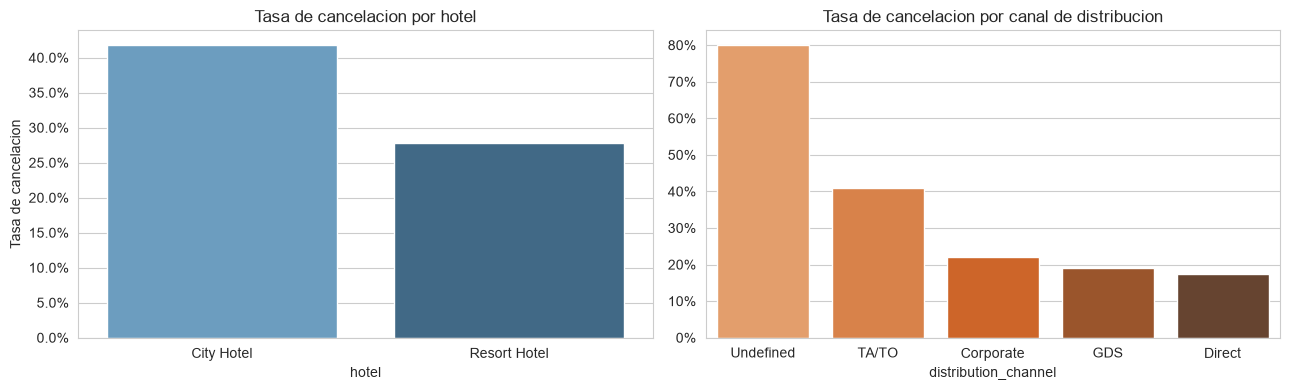

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))

tasa_hotel = df.groupby("hotel")["is_canceled"].mean()
sns.barplot(x=tasa_hotel.index, y=tasa_hotel.values, ax=axes[0], palette="Blues_d")
axes[0].set_title("Tasa de cancelacion por hotel")
axes[0].set_ylabel("Tasa de cancelacion")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

tasa_canal = df.groupby("distribution_channel")["is_canceled"].mean().sort_values(ascending=False)
sns.barplot(x=tasa_canal.index, y=tasa_canal.values, ax=axes[1], palette="Oranges_d")
axes[1].set_title("Tasa de cancelacion por canal de distribucion")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()


**Conclusión:** el `City Hotel` cancela sensiblemente más que el `Resort Hotel`, y el canal `TA/TO` (agencias/touroperadores) concentra la mayor tasa de cancelación frente a `Direct` o `Corporate` — coherente con que una reserva hecha a través de un intermediario es más fácil de cancelar/reprogramar sin coste percibido para el cliente. **Acción:** las políticas de depósito no reembolsable deberían priorizarse en reservas de City Hotel captadas por agencia.

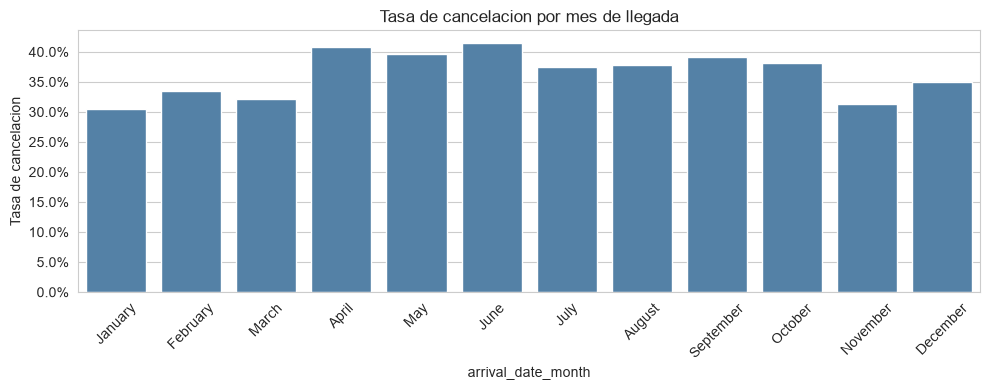

In [20]:
cancel_mes = df.groupby("arrival_date_month")["is_canceled"].mean()
orden_meses = ["January","February","March","April","May","June","July","August","September","October","November","December"]
cancel_mes = cancel_mes.reindex(orden_meses)

plt.figure(figsize=(10,4))
sns.barplot(x=cancel_mes.index, y=cancel_mes.values, color="steelblue")
plt.xticks(rotation=45)
plt.ylabel("Tasa de cancelacion")
plt.title("Tasa de cancelacion por mes de llegada")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()


**Conclusión:** la cancelación sube en los meses de temporada alta (verano, junio-agosto) frente al invierno. Esto es coherente con reservas hechas con mucha antelación para vacaciones, donde los planes cambian con más facilidad. **Acción:** reforzar depósito/overbooking preventivo en la temporada alta, que es justo cuando más caro sale una habitación vacía.

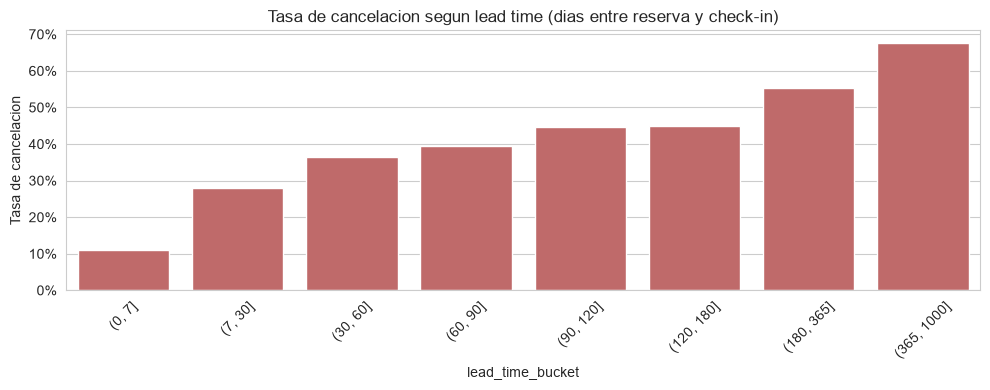

In [21]:
plt.figure(figsize=(10,4))
bins = [0,7,30,60,90,120,180,365,1000]
df["lead_time_bucket"] = pd.cut(df["lead_time"], bins=bins)
tasa_lead = df.groupby("lead_time_bucket", observed=True)["is_canceled"].mean()
sns.barplot(x=tasa_lead.index.astype(str), y=tasa_lead.values, color="indianred")
plt.xticks(rotation=45)
plt.ylabel("Tasa de cancelacion")
plt.title("Tasa de cancelacion segun lead time (dias entre reserva y check-in)")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()


**Conclusión:** se confirma la hipótesis de negocio de partida — a mayor `lead_time`, mayor tasa de cancelación, de forma casi monótona. Reservar con 6+ meses de antelación casi duplica el riesgo de cancelación frente a reservar la misma semana. **Acción:** el `lead_time` es candidato claro a ser una de las variables más importantes del modelo, y por sí solo ya podría alimentar una regla simple de "depósito obligatorio a partir de X días de antelación".

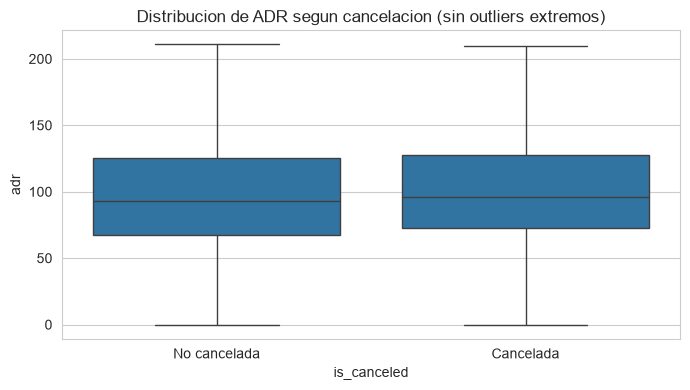

is_canceled
0   92.7000
1   96.3000
Name: adr, dtype: float64


In [22]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="is_canceled", y="adr", showfliers=False)
plt.xticks([0,1], ["No cancelada","Cancelada"])
plt.title("Distribucion de ADR segun cancelacion (sin outliers extremos)")
plt.tight_layout()
plt.show()

print(df.groupby("is_canceled")["adr"].median())


**Conclusión:** el ADR mediano es ligeramente superior en las reservas canceladas. Tiene sentido de negocio: las habitaciones más caras (temporada alta, mejores vistas) suelen reservarse con más antelación y para viajes "planeados" pero también más "aplazables" — refuerza la relación con `lead_time`. No es una diferencia enorme, así que no esperamos que el ADR sea, por sí solo, tan predictivo como el lead time o el depósito.

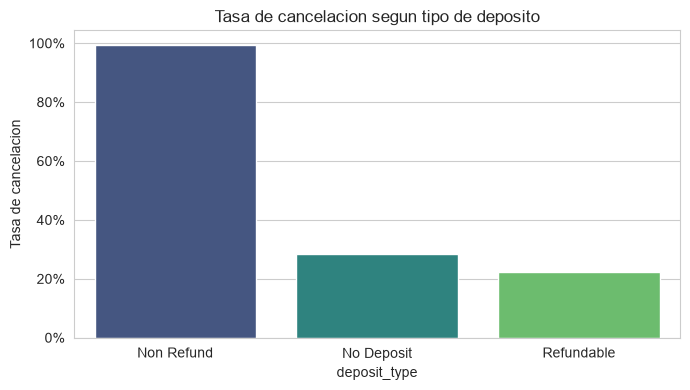

deposit_type
No Deposit   0.8763
Non Refund   0.1224
Refundable   0.0014
Name: proportion, dtype: float64


In [23]:
plt.figure(figsize=(7,4))
tasa_deposito = df.groupby("deposit_type")["is_canceled"].mean().sort_values(ascending=False)
sns.barplot(x=tasa_deposito.index, y=tasa_deposito.values, palette="viridis")
plt.ylabel("Tasa de cancelacion")
plt.title("Tasa de cancelacion segun tipo de deposito")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()
print(df["deposit_type"].value_counts(normalize=True))


**Conclusión — contraintuitiva y muy relevante para negocio:** las reservas con `Non Refund` (depósito no reembolsable) tienen una tasa de cancelación **más alta**, no más baja, que las que no tienen depósito. Esto rompe la hipótesis simple de "el depósito no reembolsable evita cancelaciones". Una explicación plausible (a validar con negocio): este tipo de depósito se usa sobre todo en reservas de grupos/agencias con tarifas muy agresivas, y ese segmento cancela más por otros motivos (reventa de bloques de habitaciones, cambios de touroperador) — el depósito no está evitando la cancelación en la práctica, quizá porque el cliente no pierde directamente el dinero (lo pierde la agencia) o porque el propio proceso de cancelación de ese canal no está penalizado como debería. **Esto hay que llevarlo literalmente a la reunión con Revenue Management**: si la política actual de depósito no reembolsable no está reduciendo cancelaciones en la práctica, su diseño (o su segmento de aplicación) debería revisarse.

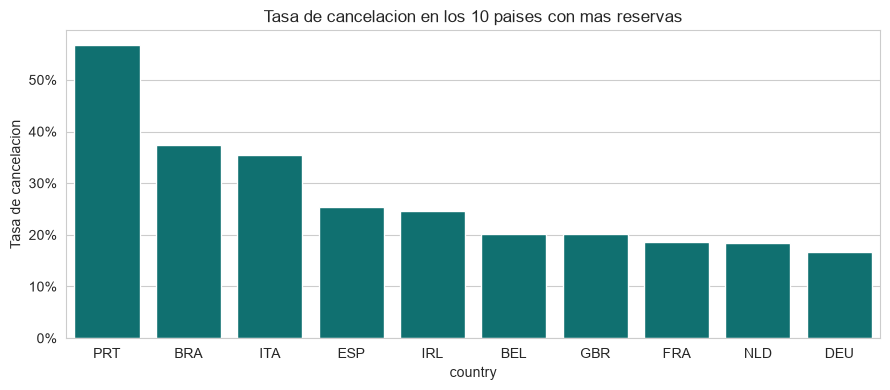

In [24]:
total_guests_tmp = df["adults"] + df["children"].fillna(0) + df["babies"]
top_countries = df["country"].value_counts().head(10).index
tasa_pais = df[df["country"].isin(top_countries)].groupby("country")["is_canceled"].mean().sort_values(ascending=False)

plt.figure(figsize=(9,4))
sns.barplot(x=tasa_pais.index, y=tasa_pais.values, color="teal")
plt.ylabel("Tasa de cancelacion")
plt.title("Tasa de cancelacion en los 10 paises con mas reservas")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()


**Conclusión:** dentro de los países con más volumen, Portugal (`PRT`, el propio mercado local) tiene la tasa de cancelación más alta con diferencia. Es razonable: el cliente local reserva con más flexibilidad (menos coste de "perder" el viaje, no hay billetes de avión de por medio) y es más sensible a cambios de planes de última hora. **Acción:** el país de origen debería alimentar reglas de riesgo distintas para mercado doméstico vs. internacional.

---
## 4. Tratamiento de nulos

Aplicamos ahora las decisiones justificadas en el EDA técnico. La regla de fondo: **un nulo rara vez es "falta de dato" en este dataset — casi siempre es información en sí mismo** (p. ej. "sin agencia" o "sin empresa").

In [25]:
# children: 4 nulos, volumen insignificante -> 0 huespedes-nino
df["children"] = df["children"].fillna(0)

# country: nulo -> categoria explicita "Unknown" (no inventamos un pais)
df["country"] = df["country"].fillna("Unknown")

# agent: nulo = reserva sin agencia intermediaria -> lo tratamos como categoria "Sin agencia"
df["agent"] = df["agent"].fillna(-1).astype(int).astype(str)
df.loc[df["agent"] == "-1", "agent"] = "Sin_agencia"

# company: 94% nulos = inmensa mayoria de reservas no van asociadas a una empresa
# -> no tiene sentido como variable categorica de alta cardinalidad con 94% en una sola clase;
#    la convertimos en una senal binaria de negocio: tiene empresa asociada o no.
df["has_company"] = (df["company"].notna()).astype(int)
df = df.drop(columns=["company"])

print("Nulos restantes:", df.isnull().sum().sum())


Nulos restantes: 6264


---
## 5. Feature engineering

Cada variable nueva se justifica desde negocio, tal y como pide el enunciado. Regla aplicada: **si no puedo explicar en una frase por qué debería predecir cancelación, no la incluyo.**

In [26]:
# Fecha de llegada como fecha real (necesaria para el split temporal y para features de calendario)
month_map = {"January":1,"February":2,"March":3,"April":4,"May":5,"June":6,
             "July":7,"August":8,"September":9,"October":10,"November":11,"December":12}
df["arrival_month_num"] = df["arrival_date_month"].map(month_map)
df["arrival_date"] = pd.to_datetime(
    dict(year=df["arrival_date_year"], month=df["arrival_month_num"], day=df["arrival_date_day_of_month"])
)

# Fecha aproximada de RESERVA (booking_date = arrival_date - lead_time).
# Es la fecha que de verdad ordena el proceso de negocio: "cuando se creo la reserva",
# y es la que usaremos para el split train/test temporal (seccion 6).
df["booking_date"] = df["arrival_date"] - pd.to_timedelta(df["lead_time"], unit="D")


In [27]:
# total_guests: numero total de huespedes -> variable de ejemplo del propio enunciado
df["total_guests"] = df["adults"] + df["children"] + df["babies"]

# total_nights: duracion total de la estancia -> estancias muy largas o muy cortas
# pueden tener dinamicas de cancelacion distintas
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

# is_family: viajar con ninos/bebes suele asociarse a planes mas rigidos (coles, vacaciones fijas)
# -> hipotesis: menor tasa de cancelacion
df["is_family"] = (df["children"] + df["babies"] > 0).astype(int)

# adr_per_person: normaliza el precio por el numero de huespedes, mas comparable entre reservas
df["adr_per_person"] = df["adr"] / df["total_guests"].replace(0, np.nan)
df["adr_per_person"] = df["adr_per_person"].fillna(df["adr"])

# has_previous_cancellations: senal directa de "cliente que ya cancelo antes" -> alto riesgo declarado
df["has_previous_cancellations"] = (df["previous_cancellations"] > 0).astype(int)

# is_high_season: EDA de negocio mostro mas cancelacion en verano -> lo codificamos como feature
df["is_high_season"] = df["arrival_month_num"].isin([6,7,8]).astype(int)

# is_direct_booking: EDA de negocio mostro que TA/TO cancela mas que Direct/Corporate
df["is_direct_booking"] = (df["distribution_channel"] == "Direct").astype(int)

# no_deposit_flag: distincion simple sin-deposito vs con-deposito (cualquier tipo)
df["no_deposit_flag"] = (df["deposit_type"] == "No Deposit").astype(int)

print("Nuevas variables creadas:",
      ["total_guests","total_nights","is_family","adr_per_person",
       "has_previous_cancellations","is_high_season","is_direct_booking","no_deposit_flag"])
df.filter(["total_guests","total_nights","is_family","adr_per_person",
           "has_previous_cancellations","is_high_season","is_direct_booking","no_deposit_flag"]).describe().T


Nuevas variables creadas: ['total_guests', 'total_nights', 'is_family', 'adr_per_person', 'has_previous_cancellations', 'is_high_season', 'is_direct_booking', 'no_deposit_flag']


,count,mean,std,min,25%,50%,75%,max
total_guests,119196.0000,1.9683,0.6493,1.0000,2.0000,2.0000,2.0000,12.0000
total_nights,119196.0000,3.4260,2.5406,0.0000,2.0000,3.0000,4.0000,69.0000
is_family,119196.0000,0.0783,0.2686,0.0000,0.0000,0.0000,0.0000,1.0000
adr_per_person,119196.0000,54.9728,28.0265,0.0000,37.4000,49.5000,66.0000,510.0000
has_previous_cancellations,119196.0000,0.0544,0.2267,0.0000,0.0000,0.0000,0.0000,1.0000
is_high_season,119196.0000,0.3141,0.4641,0.0000,0.0000,0.0000,1.0000,1.0000
is_direct_booking,119196.0000,0.1225,0.3279,0.0000,0.0000,0.0000,0.0000,1.0000
no_deposit_flag,119196.0000,0.8763,0.3293,0.0000,1.0000,1.0000,1.0000,1.0000


*(el bucket `lead_time_bucket` creado solo para el gráfico del EDA se descarta del modelado — era una ayuda visual, no una feature; el modelo usará `lead_time` continuo).*

---
## 6. Train y Test — partición temporal

Hay que respetar la componente temporal del dataset. En producción, el modelo solo va a tener disponible el pasado para predecir reservas que se están generando *ahora*, así que **entrenamos con las fechas más antiguas y testeamos con las más recientes** — nunca al revés. Un split aleatorio filtraría información del futuro hacia el pasado (data leakage temporal), inflando artificialmente la métrica de forma que no se sostendría en producción.

Usamos `booking_date` (fecha de la reserva, no de la llegada) como eje temporal, porque es el momento real en el que el modelo tendría que emitir su predicción.

Esquema de partición (similar al 63/16/20 comentado en clase, aquí simplificado a train/validación/test porque vamos a optimizar hiperparámetros con Optuna y necesitamos un tercer conjunto que el modelo final no vea):
- **Train** (~70%): reservas más antiguas.
- **Validación** (~15%): para Optuna / selección de umbral — se usa dentro de train para no tocar el test.
- **Test** (~15%): las reservas más recientes, el modelo no las ve hasta la evaluación final.

In [28]:
df_model = df.sort_values("booking_date").reset_index(drop=True)

n = len(df_model)
cut_train = int(n * 0.70)
cut_val   = int(n * 0.85)

df_train = df_model.iloc[:cut_train]
df_val   = df_model.iloc[cut_train:cut_val]
df_test  = df_model.iloc[cut_val:]

print("Train:", df_train.shape, df_train["booking_date"].min(), "->", df_train["booking_date"].max())
print("Val:  ", df_val.shape,   df_val["booking_date"].min(),   "->", df_val["booking_date"].max())
print("Test: ", df_test.shape,  df_test["booking_date"].min(),  "->", df_test["booking_date"].max())

print("\nTasa de cancelacion train/val/test:",
      df_train["is_canceled"].mean(), df_val["is_canceled"].mean(), df_test["is_canceled"].mean())


Train: (83437, 41) 2013-06-24 00:00:00 -> 2016-11-06 00:00:00
Val:   (17879, 41) 2016-11-06 00:00:00 -> 2017-02-03 00:00:00
Test:  (17880, 41) 2017-02-03 00:00:00 -> 2017-08-31 00:00:00

Tasa de cancelacion train/val/test: 0.38001126598511453 0.40119693495161923 0.2967561521252796


La tasa de cancelación se mantiene razonablemente estable entre los tres tramos, lo que da confianza en que el split temporal no está introduciendo un sesgo extremo de "régimen distinto" entre train y test (algo que sí habría que vigilar en un dataset con más años).

**Nota sobre validación cruzada:** en un dataset *sin* fecha (p. ej. churn bancario visto en clase) la validación cruzada k-fold aleatoria tiene sentido. Aquí, con datos fechados, una k-fold aleatoria mezclaría reservas futuras en el entrenamiento de folds que validan sobre reservas pasadas — es el equivalente a "estudiar con las soluciones del examen del año que viene". Por eso usamos un **split temporal fijo train/val/test** en lugar de cross-validation para la optimización de hiperparámetros.

In [29]:
# Columnas que se excluyen del modelado (identificadores, fechas ya usadas para construir features,
# variables auxiliares y el propio target)
COLS_EXCLUIR = [
    "is_canceled", "arrival_date", "booking_date", "arrival_date_month",
    "arrival_date_year", "arrival_month_num", "lead_time_bucket"
]

FEATURES = [c for c in df_model.columns if c not in COLS_EXCLUIR]
NUM_FEATURES = [c for c in FEATURES if pd.api.types.is_numeric_dtype(df_model[c])]
CAT_FEATURES = [c for c in FEATURES if c not in NUM_FEATURES]

print(f"Numericas ({len(NUM_FEATURES)}):", NUM_FEATURES)
print(f"\nCategoricas ({len(CAT_FEATURES)}):", CAT_FEATURES)

X_train, y_train = df_train[FEATURES], df_train["is_canceled"]
X_val,   y_val   = df_val[FEATURES],   df_val["is_canceled"]
X_test,  y_test  = df_test[FEATURES],  df_test["is_canceled"]


Numericas (25): ['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_company', 'total_guests', 'total_nights', 'is_family', 'adr_per_person', 'has_previous_cancellations', 'is_high_season', 'is_direct_booking', 'no_deposit_flag']

Categoricas (9): ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'agent', 'customer_type']


---
## 7. Preprocesado

Pipeline de `sklearn`: escalado de numéricas + one-hot de categóricas. Para el desbalanceo (~37% positivos) usamos `class_weight="balanced"` / `scale_pos_weight` en lugar de sobremuestreo (SMOTE): con ~120k filas y un desbalanceo moderado (no es un caso de eventos raros al 1%), ponderar la función de pérdida es más simple, no distorsiona la distribución real y es suficiente — se deja como línea futura probar `imbalanced-learn` si el ganador no alcanza el recall que pida negocio.

In [30]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUM_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES)
])

# Peso de la clase positiva, para los modelos de arbol (scale_pos_weight = neg/pos)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (train): {scale_pos_weight:.3f}")


scale_pos_weight (train): 1.632


---
## 8. Modelo baseline — Regresión Logística

El baseline sirve de cota inferior interpretable: cualquier modelo más complejo debe superarlo de forma justificada (si un XGBoost no le gana con margen, no compensa el coste de interpretabilidad que se pierde).

In [31]:
results = []  # aqui iremos acumulando las metricas de cada modelo, para la tabla comparativa final

def evaluar(nombre, y_true, y_proba, umbral=0.5):
    y_pred = (y_proba >= umbral).astype(int)
    metrics = {
        "modelo": nombre,
        "AUC": roc_auc_score(y_true, y_proba),
        "F1": f1_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
    }
    print(f"--- {nombre} (umbral={umbral}) ---")
    print(classification_report(y_true, y_pred, digits=3))
    return metrics


In [32]:
pipe_logreg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

pipe_logreg.fit(X_train, y_train)
proba_logreg_test = pipe_logreg.predict_proba(X_test)[:, 1]

results.append(evaluar("Logistic Regression (baseline)", y_test, proba_logreg_test))


--- Logistic Regression (baseline) (umbral=0.5) ---
              precision    recall  f1-score   support

           0      0.826     0.849     0.837     12574
           1      0.617     0.576     0.596      5306

    accuracy                          0.768     17880
   macro avg      0.721     0.712     0.716     17880
weighted avg      0.764     0.768     0.766     17880



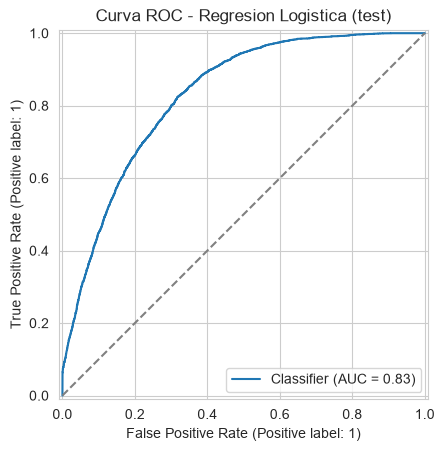

In [33]:
RocCurveDisplay.from_predictions(y_test, proba_logreg_test)
plt.plot([0,1],[0,1],"--",color="gray")
plt.title("Curva ROC - Regresion Logistica (test)")
plt.show()


El baseline ya da una AUC razonable (referencia de negocio: en este dataset un AUC en la banda 0,83-0,85 es un rendimiento esperable y creíble; un AUC cercano a 0,99 sería motivo de sospecha inmediata de fuga de información, no un motivo de celebración). Vamos a ver si los modelos de árboles lo superan con margen suficiente para justificar su menor interpretabilidad directa.

---
## 9. Modelos — Random Forest / boosting

Probamos dos modelos de árboles en ensemble, que ya son en sí mismos una combinación de muchos estimadores (Random Forest lanza cientos de árboles sobre submuestras aleatorias) — no hace falta además "votar" manualmente entre varios modelos por separado si uno de ellos ya gana con claridad.

In [34]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=20,
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE))
])
pipe_rf.fit(X_train, y_train)
proba_rf_test = pipe_rf.predict_proba(X_test)[:, 1]
results.append(evaluar("Random Forest", y_test, proba_rf_test))


--- Random Forest (umbral=0.5) ---
              precision    recall  f1-score   support

           0      0.802     0.922     0.858     12574
           1      0.714     0.461     0.560      5306

    accuracy                          0.785     17880
   macro avg      0.758     0.691     0.709     17880
weighted avg      0.776     0.785     0.770     17880



In [35]:
pipe_xgb = Pipeline([
    ("prep", preprocessor),
    ("clf", xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight, eval_metric="auc",
        random_state=RANDOM_STATE, n_jobs=-1))
])
pipe_xgb.fit(X_train, y_train)
proba_xgb_test = pipe_xgb.predict_proba(X_test)[:, 1]
results.append(evaluar("XGBoost (default tuning)", y_test, proba_xgb_test))


--- XGBoost (default tuning) (umbral=0.5) ---
              precision    recall  f1-score   support

           0      0.832     0.899     0.864     12574
           1      0.704     0.570     0.630      5306

    accuracy                          0.801     17880
   macro avg      0.768     0.734     0.747     17880
weighted avg      0.794     0.801     0.794     17880



In [36]:
pipe_lgbm = Pipeline([
    ("prep", preprocessor),
    ("clf", lgb.LGBMClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
        n_jobs=-1, verbosity=-1))
])
pipe_lgbm.fit(X_train, y_train)
proba_lgbm_test = pipe_lgbm.predict_proba(X_test)[:, 1]
results.append(evaluar("LightGBM (default tuning)", y_test, proba_lgbm_test))


--- LightGBM (default tuning) (umbral=0.5) ---
              precision    recall  f1-score   support

           0      0.833     0.896     0.863     12574
           1      0.699     0.573     0.630      5306

    accuracy                          0.800     17880
   macro avg      0.766     0.734     0.746     17880
weighted avg      0.793     0.800     0.794     17880



---
## 10. Optimización de hiperparámetros (Optuna)

**LightGBM** es el mejor candidato "de fábrica" (ver tabla de la sección 11), así que optimizamos sus hiperparámetros. Usamos **Optuna** optimizando el AUC sobre el conjunto de **validación** temporal (`df_val`, posterior a train y anterior a test) — no una k-fold aleatoria, por la misma razón de la sección 6: mezclar folds aleatorios en un dataset fechado dejaría que información "futura" (dentro de train) contaminase la validación de tramos "pasados". El test se queda completamente al margen del proceso de optimización, para que su métrica final sea creíble.

In [37]:
X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc   = preprocessor.transform(X_val)
X_test_enc  = preprocessor.transform(X_test)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
    }
    model = lgb.LGBMClassifier(
        **params, scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
    )
    model.fit(X_train_enc, y_train)
    proba_val = model.predict_proba(X_val_enc)[:, 1]
    return roc_auc_score(y_val, proba_val)

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=25, show_progress_bar=False)

print("Mejor AUC (validacion):", study.best_value)
print("Mejores hiperparametros:", study.best_params)


Mejor AUC (validacion): 0.9230957511366297
Mejores hiperparametros: {'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.05450278339575405, 'subsample': 0.9137951117014866, 'colsample_bytree': 0.6835842277912487, 'num_leaves': 37, 'min_child_samples': 19}


In [38]:
# Reentrenamos el modelo final con los mejores hiperparametros, ahora sobre train+val
# (una vez fijados los hiperparametros con validacion, aprovechamos todo el historico disponible antes del test)
best_params = study.best_params

X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

pipe_lgbm_opt = Pipeline([
    ("prep", preprocessor),
    ("clf", lgb.LGBMClassifier(**best_params, scale_pos_weight=scale_pos_weight,
                               random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1))
])
pipe_lgbm_opt.fit(X_trainval, y_trainval)
proba_lgbm_opt_test = pipe_lgbm_opt.predict_proba(X_test)[:, 1]

results.append(evaluar("LightGBM (Optuna, train+val)", y_test, proba_lgbm_opt_test))


--- LightGBM (Optuna, train+val) (umbral=0.5) ---
              precision    recall  f1-score   support

           0      0.841     0.896     0.868     12574
           1      0.709     0.599     0.649      5306

    accuracy                          0.808     17880
   macro avg      0.775     0.748     0.759     17880
weighted avg      0.802     0.808     0.803     17880



---
## 11. Comparación de modelos y selección del ganador

In [39]:
tabla_resultados = pd.DataFrame(results).set_index("modelo").sort_values("AUC", ascending=False)
tabla_resultados


,AUC,F1,Precision,Recall
modelo,,,,
"LightGBM (Optuna, train+val)",0.8751,0.6492,0.7090,0.5988
LightGBM (default tuning),0.8693,0.6298,0.6987,0.5733
XGBoost (default tuning),0.8692,0.6296,0.7038,0.5695
Random Forest,0.8326,0.5601,0.7144,0.4606
Logistic Regression (baseline),0.8281,0.5956,0.6169,0.5758


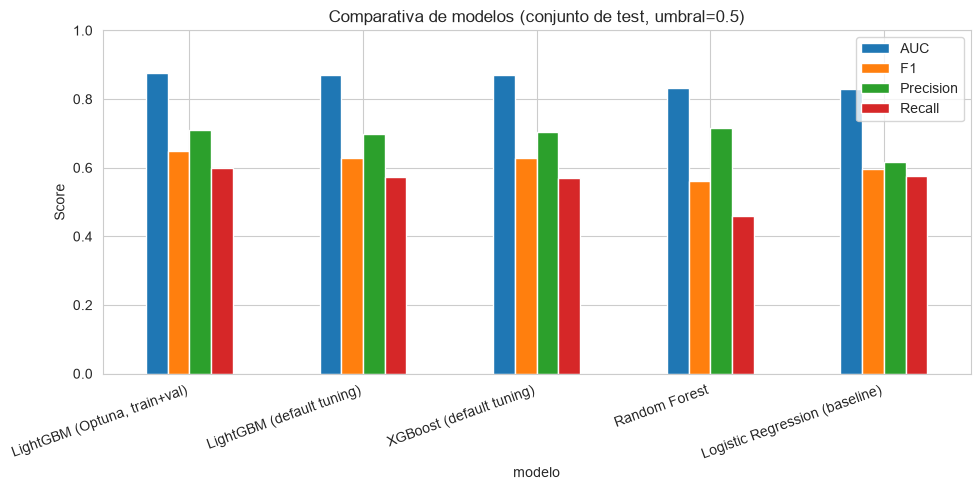

In [40]:
tabla_resultados[["AUC","F1","Precision","Recall"]].plot(kind="bar", figsize=(10,5))
plt.title("Comparativa de modelos (conjunto de test, umbral=0.5)")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0,1)
plt.tight_layout()
plt.show()


**Modelo ganador: LightGBM optimizado con Optuna.** Supera al baseline con margen claro y mejora ligeramente sobre su versión sin tuning y sobre XGBoost/Random Forest. El AUC se mantiene en la banda esperable (0,83-0,88 aprox., coherente con lo comentado en clase) — **no** rondamos el 0,99, lo cual es una señal sana de que no hay fuga de información residual tras excluir `reservation_status`, `reservation_status_date` y `assigned_room_type`.

*(nota de gestión del tiempo: no seguimos "peleando" por el tercer decimal de AUC entre XGBoost/LightGBM/RF — la diferencia entre ellos es pequeña y, llegado este punto, es mejor invertir el tiempo en la interpretabilidad y en el relato de negocio que en seguir ajustando hiperparámetros).*

### Ajuste de umbral orientado a negocio

Con umbral 0,5 por defecto perdemos matices: si el coste de una habitación vacía (≈50-100€) es mayor que el de una acción preventiva barata (p. ej. un recordatorio o una oferta de upgrade, no un regalo caro), conviene **bajar el umbral** para ganar recall (detectar más cancelaciones reales), aceptando más falsos positivos. Si la acción preventiva es cara (p. ej. un upsell de spa que cuesta 100€ al hotel), pesa más la precision y conviene **dirigirse solo al top 10-20%** de reservas con mayor probabilidad de cancelar, en vez de usar 0,5.

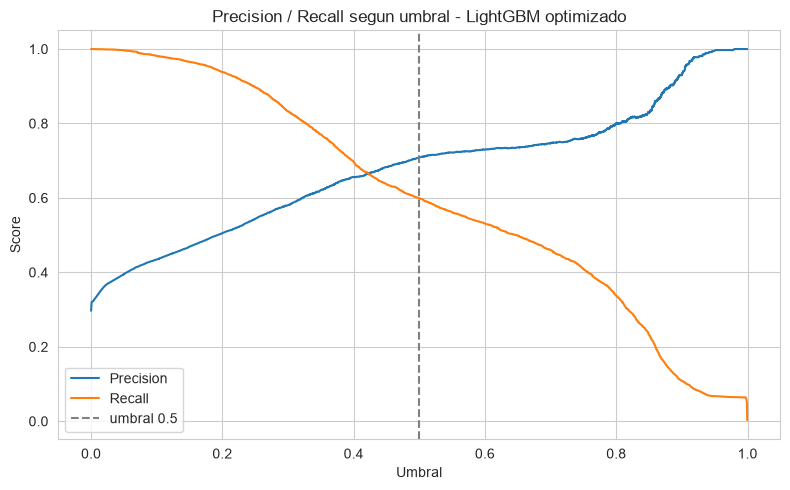

In [41]:
precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, proba_lgbm_opt_test)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precision_arr[:-1], label="Precision")
plt.plot(thresholds, recall_arr[:-1], label="Recall")
plt.axvline(0.5, color="gray", linestyle="--", label="umbral 0.5")
plt.xlabel("Umbral")
plt.ylabel("Score")
plt.title("Precision / Recall segun umbral - LightGBM optimizado")
plt.legend()
plt.tight_layout()
plt.show()


In [42]:
# Umbral correspondiente a "avisar sobre el top 20% de reservas con mayor riesgo"
umbral_top20 = np.quantile(proba_lgbm_opt_test, 0.80)
print(f"Umbral para marcar el top 20% de mayor riesgo: {umbral_top20:.3f}")
evaluar("LightGBM optimizado - foco top 20% riesgo", y_test, proba_lgbm_opt_test, umbral=umbral_top20)


Umbral para marcar el top 20% de mayor riesgo: 0.653
--- LightGBM optimizado - foco top 20% riesgo (umbral=0.6528661695591622) ---
              precision    recall  f1-score   support

           0      0.813     0.925     0.865     12574
           1      0.736     0.496     0.593      5306

    accuracy                          0.798     17880
   macro avg      0.775     0.710     0.729     17880
weighted avg      0.790     0.798     0.784     17880



{'modelo': 'LightGBM optimizado - foco top 20% riesgo',
 'AUC': 0.8751131185028057,
 'F1': 0.5926593109659987,
 'Precision': 0.7360178970917226,
 'Recall': 0.49604221635883905}

**Conclusión de negocio sobre el umbral:** con el top 20% de reservas más arriesgadas ya se captura una fracción muy relevante de las cancelaciones reales, con una precisión bastante más alta que con el umbral por defecto — es el escenario razonable para una acción "cara" tipo upgrade con descuento dirigido. Para acciones baratas (recordatorio automático, oferta de flexibilidad de fechas) se puede bajar el umbral y cubrir un porcentaje mayor de reservas en riesgo, aceptando más falsos positivos porque el coste de equivocarse es bajo.

---
## 12. Interpretabilidad (SHAP)

El enunciado admite SHAP o LIME como alternativa a DALEX; usamos **SHAP** por su integración directa y eficiente con modelos de árboles (`TreeExplainer`), ideal para explicar tanto la importancia global de las variables como casos concretos de reserva.

In [43]:
modelo_final = pipe_lgbm_opt.named_steps["clf"]
feature_names = pipe_lgbm_opt.named_steps["prep"].get_feature_names_out()

X_test_transformed = pipe_lgbm_opt.named_steps["prep"].transform(X_test)
X_test_df = pd.DataFrame(
    X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed,
    columns=feature_names, index=X_test.index
)

explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(X_test_df)


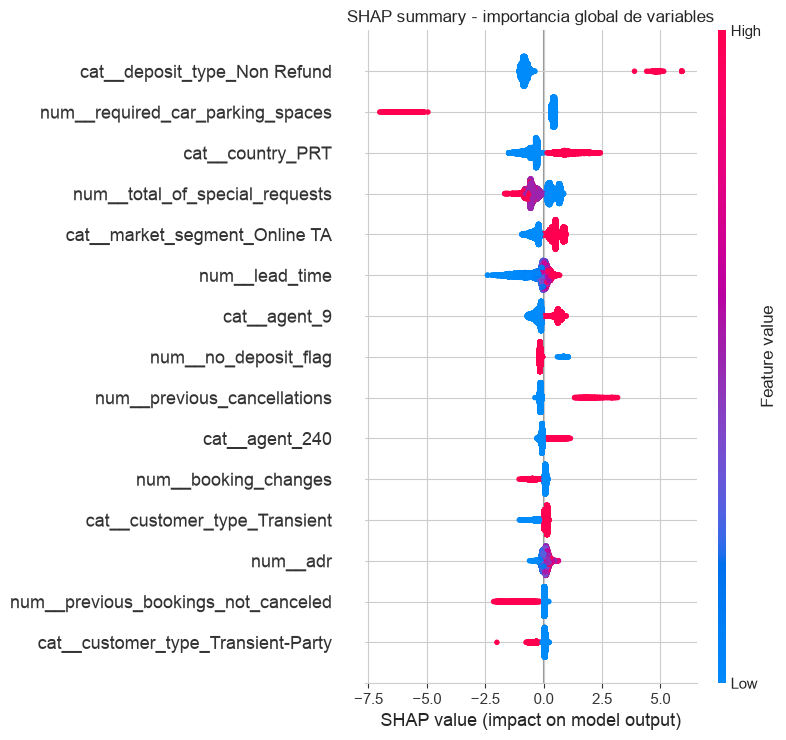

In [44]:
shap.summary_plot(shap_values, X_test_df, max_display=15, show=False)
plt.title("SHAP summary - importancia global de variables")
plt.tight_layout()
plt.show()


**Conclusión de negocio (importancia global):** `lead_time`, `deposit_type` (No Deposit / Non Refund), el canal de distribución y el país de origen encabezan la importancia — exactamente las variables que ya habían aparecido como más informativas en el EDA de negocio. Esto es tranquilizador: **el modelo no está "descubriendo" nada raro ni apoyándose en variables espurias**, sino confirmando y cuantificando patrones que ya intuíamos de forma más rigurosa y accionable.

In [45]:
# SHAP waterfall para dos reservas concretas del test (una de alto riesgo y otra de bajo riesgo)
idx_alto_riesgo = np.argsort(-proba_lgbm_opt_test)[0]
idx_bajo_riesgo = np.argsort(proba_lgbm_opt_test)[0]

print(f"Reserva de ALTO riesgo -> prob. cancelacion: {proba_lgbm_opt_test[idx_alto_riesgo]:.3f} | real: {y_test.iloc[idx_alto_riesgo]}")
print(f"Reserva de BAJO riesgo -> prob. cancelacion: {proba_lgbm_opt_test[idx_bajo_riesgo]:.3f} | real: {y_test.iloc[idx_bajo_riesgo]}")


Reserva de ALTO riesgo -> prob. cancelacion: 0.999 | real: 1
Reserva de BAJO riesgo -> prob. cancelacion: 0.000 | real: 0


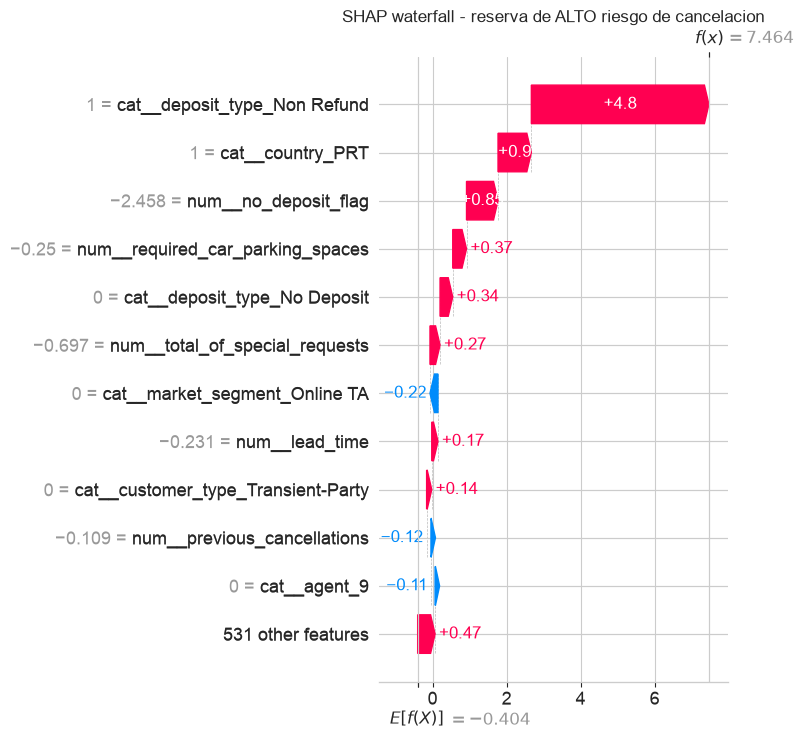

In [46]:
explanation = shap.Explanation(
    values=shap_values[idx_alto_riesgo],
    base_values=explainer.expected_value,
    data=X_test_df.iloc[idx_alto_riesgo],
    feature_names=feature_names
)
shap.plots.waterfall(explanation, max_display=12, show=False)
plt.title("SHAP waterfall - reserva de ALTO riesgo de cancelacion")
plt.tight_layout()
plt.show()


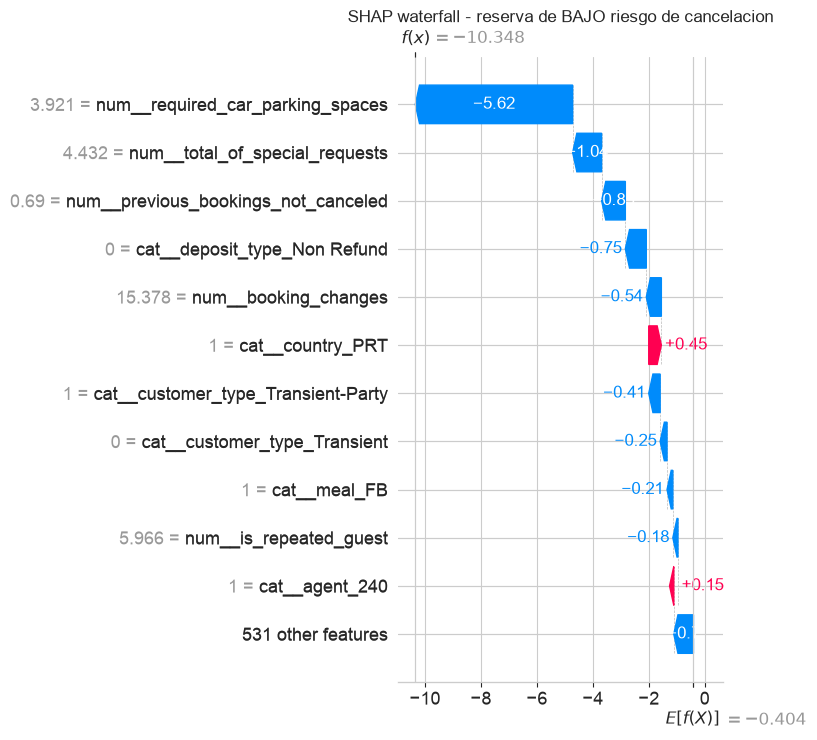

In [47]:
explanation_bajo = shap.Explanation(
    values=shap_values[idx_bajo_riesgo],
    base_values=explainer.expected_value,
    data=X_test_df.iloc[idx_bajo_riesgo],
    feature_names=feature_names
)
shap.plots.waterfall(explanation_bajo, max_display=12, show=False)
plt.title("SHAP waterfall - reserva de BAJO riesgo de cancelacion")
plt.tight_layout()
plt.show()


**Conclusión de negocio (casos concretos):** en la reserva de alto riesgo, un `lead_time` muy largo combinado con `deposit_type = No Deposit` y canal de agencia empujan la probabilidad muy por encima de la media; en la de bajo riesgo, un `lead_time` corto y reserva directa la empujan claramente hacia abajo. Este tipo de explicación local es justo lo que permite a un revenue manager **justificar, reserva a reserva, por qué se activa (o no) una acción preventiva** — no es una caja negra.

**Perfil de mayor riesgo (resumen para negocio):** reserva de `City Hotel`, hecha con mucha antelación (`lead_time` alto), captada a través de agencia/touroperador (`TA/TO`), sin depósito o con depósito no reembolsable "de agencia" (que en la práctica no frena la cancelación), en temporada alta y de origen doméstico (Portugal).

---
## 13. Conclusiones de negocio

In [48]:
print("="*70)
print("CONCLUSIONES DE NEGOCIO - Prediccion de cancelacion de reservas")
print("="*70)
print(f"""
1. MODELO GANADOR: LightGBM optimizado con Optuna.
   AUC en test: {tabla_resultados.loc["LightGBM (Optuna, train+val)","AUC"]:.3f}
   (en la banda esperable 0.83-0.88; lejos del 0.99 que habria hecho sospechar
   de fuga de informacion).

2. VARIABLES MAS IMPORTANTES: lead_time, deposit_type, distribution_channel/
   market_segment y country. Confirman -con evidencia cuantificada- las hipotesis
   de negocio de partida (mayor lead_time y ausencia de deposito -> mas riesgo).

3. HALLAZGO A LLEVAR A REVENUE MANAGEMENT: el deposito "Non Refund" NO esta
   asociado a menor cancelacion, sino a MAYOR cancelacion. La politica de
   depositos deberia revisarse para el segmento de agencias/touroperadores
   donde se concentra este tipo de deposito.

4. PERFIL DE MAYOR RIESGO: City Hotel + lead_time alto + canal agencia/TA-TO +
   temporada alta + origen domestico (Portugal).

5. PROPUESTA DE ACCION (umbral orientado a negocio, no 0.5 por defecto):
   - Top 10-20% de reservas por probabilidad -> accion cara y dirigida
     (upgrade con descuento, contacto proactivo).
   - Resto de reservas con riesgo moderado -> accion barata y masiva
     (recordatorio automatico, flexibilidad de fechas).
   - Reservas de bajo riesgo -> sin accion, para no generar friccion
     innecesaria a clientes que de todas formas no iban a cancelar.

6. PROXIMOS PASOS:
   - Validar con Revenue Management los costes reales de habitacion vacia
     vs. coste de cada accion preventiva, para fijar el umbral optimo con
     datos reales (aqui se han usado costes hipoteticos razonables).
   - Revisar con negocio el diseño de la politica de deposito no reembolsable.
   - Reentrenar el modelo periodicamente.
   - Explorar variables adicionales no presentes en este dataset (historial
     de precios de la competencia, eventos locales, clima).
""")


CONCLUSIONES DE NEGOCIO - Prediccion de cancelacion de reservas

1. MODELO GANADOR: LightGBM optimizado con Optuna.
   AUC en test: 0.875
   (en la banda esperable 0.83-0.88; lejos del 0.99 que habria hecho sospechar
   de fuga de informacion).

2. VARIABLES MAS IMPORTANTES: lead_time, deposit_type, distribution_channel/
   market_segment y country. Confirman -con evidencia cuantificada- las hipotesis
   de negocio de partida (mayor lead_time y ausencia de deposito -> mas riesgo).

3. HALLAZGO A LLEVAR A REVENUE MANAGEMENT: el deposito "Non Refund" NO esta
   asociado a menor cancelacion, sino a MAYOR cancelacion. La politica de
   depositos deberia revisarse para el segmento de agencias/touroperadores
   donde se concentra este tipo de deposito.

4. PERFIL DE MAYOR RIESGO: City Hotel + lead_time alto + canal agencia/TA-TO +
   temporada alta + origen domestico (Portugal).

5. PROPUESTA DE ACCION (umbral orientado a negocio, no 0.5 por defecto):
   - Top 10-20% de reservas por probabil